# The Geometry of V1 Population Activity in the MICrONS Dataset
## Low-dimensional structure, stimulus specificity, and its anatomical basis

This notebook investigates two central questions about population coding in mouse primary visual cortex (V1) using the MICrONS two-photon calcium imaging dataset:

- **Q1 – Effective dimensionality**: How many dimensions does V1 population activity occupy, and does this differ across stimulus types (Clip = natural movies, Monet2 = synthetic oriented noise, Trippy = phase-patterned video)?
- **Q2 – Subspace geometry**: Do the three stimulus classes activate the same region of population state-space, or do they occupy distinct representational geometries?

All analysis is restricted to **session 7_4**, the largest session (~7,700 V1 neurons). The primary tools are Principal Component Analysis (PCA), participation ratio, cumulative variance explained, and principal angles between stimulus-specific subspaces.

## 0. Imports and Setup

In [15]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.linalg import subspace_angles
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

import microns_datacleaner as mic

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
RNG = np.random.default_rng(42)

# ── Plot aesthetics ───────────────────────────────────────────────────────────
sns.set_theme(style='ticks', context='notebook', font_scale=1.15)
COLORS = {'Clip': '#2166ac', 'Monet2': '#d6604d', 'Trippy': '#1a9641'}
STIM_TYPES = ['Clip', 'Monet2', 'Trippy']

# ── Session ───────────────────────────────────────────────────────────────────
SESSION = '7_4'
BRAIN_AREA = 'V1'

# ── Data paths ────────────────────────────────────────────────────────────────
PROJECT_DIR = Path().resolve()
DATA_DIR    = PROJECT_DIR / 'data'
H5_PATH     = DATA_DIR / 'functional' / 'microns_functional.h5'
ANAT_DIR    = DATA_DIR / '1718'

print(f'Project directory : {PROJECT_DIR}')
print(f'H5 file expected  : {H5_PATH}')
print(f'File exists       : {H5_PATH.exists()}')

Project directory : /Users/federicoscaffidimuta/Desktop/Third year/NS project/lowdim-neuron-dynamics
H5 file expected  : /Users/federicoscaffidimuta/Desktop/Third year/NS project/lowdim-neuron-dynamics/data/functional/microns_functional.h5
File exists       : True


## 1. Data Download (run once)

The functional data is a single HDF5 file (~20 GB) hosted on HuggingFace. Run the cell below **once** to download it. Skip if `H5_PATH.exists()` is already `True`.

In [16]:
if not H5_PATH.exists():
    print('Downloading microns_functional.h5 (~20 GB). This will take a while...')
    (DATA_DIR / 'functional').mkdir(parents=True, exist_ok=True)

    # Import the downloader directly – avoids CAVEclient auth (only needed for anatomy tables).
    from microns_datacleaner.downloader import download_functional_data
    download_functional_data(str(H5_PATH))
    print('Download complete.')
else:
    print('H5 file already present – skipping download.')

H5 file already present – skipping download.


## 2. Load Functional Data and Inspect Session 7_4

In [17]:
funcreader = mic.MicronsFunctionalReader(datadir='data')

# High-level structure inspection
print('Available brain areas (all sessions):', funcreader.get_available_brain_areas())
print('Brain areas in session', SESSION, ':', funcreader.get_available_brain_areas(SESSION))

Available brain areas (all sessions): ['AL', 'LM', 'RL', 'V1']
Brain areas in session 7_4 : ['AL', 'LM', 'RL', 'V1']


### 2.1 Categorise every trial by stimulus type

`get_hashes_by_session` returns one hash per trial in order (repeats included). Iterating over them and checking `get_video_type` assigns each trial to Clip, Monet2, or Trippy.

In [18]:
hashes = funcreader.get_hashes_by_session(SESSION)   # one entry per trial

trial_indices = {'Clip': [], 'Monet2': [], 'Trippy': []}

for trial_idx, h in enumerate(hashes):
    stim = funcreader.get_video_type(h)
    if stim in trial_indices:
        trial_indices[stim].append(trial_idx)

for stim, idx_list in trial_indices.items():
    print(f'{stim:8s}: {len(idx_list):4d} trials')

Clip    :  384 trials
Monet2  :   40 trials
Trippy  :   40 trials


## 3. Build Population Response Matrices

For each trial we:
1. Load the neural response matrix `(n_neurons × n_frames)`.
2. Average across frames to obtain a single population state vector per trial.
3. Also record mean treadmill speed and mean pupil diameter for behavioural regression.

The result for each stimulus class is a matrix **R** of shape `(n_trials × n_V1_neurons)`.

In [19]:
def build_response_matrix(session, trial_idx_list, brain_area='V1', verbose=True):
    """
    Returns
    -------
    R        : (n_trials, n_neurons)   – mean response per trial
    running  : (n_trials,)             – mean treadmill speed per trial
    pupil    : (n_trials,)             – mean pupil diameter per trial
    """
    R_rows, run_vals, pup_vals = [], [], []

    for i, t in enumerate(trial_idx_list):
        if verbose and i % 50 == 0:
            print(f'  loading trial {i+1}/{len(trial_idx_list)}...', end='\r')

        trial = funcreader.get_trial(session, t, brain_area=brain_area)
        # responses: (n_neurons, n_frames)  →  mean over frames
        R_rows.append(trial['responses'].mean(axis=1))
        run_vals.append(float(np.nanmean(trial['treadmill'])))
        pup_vals.append(float(np.nanmean(trial['pupil'])))

    if verbose:
        print()
    return np.vstack(R_rows), np.array(run_vals), np.array(pup_vals)

In [20]:
raw_data = {}
for stim in STIM_TYPES:
    print(f'Loading {stim}…')
    R, run, pup = build_response_matrix(SESSION, trial_indices[stim])
    raw_data[stim] = {'R': R, 'run': run, 'pup': pup}
    print(f'  {stim}: R.shape = {R.shape}')

Loading Clip…
  loading trial 351/384...
  Clip: R.shape = (384, 7725)
Loading Monet2…
  loading trial 1/40...
  Monet2: R.shape = (40, 7725)
Loading Trippy…
  loading trial 1/40...
  Trippy: R.shape = (40, 7725)


## 4. Preprocessing

**Step 1 – Z-score per neuron** across *all* trials (pooling stimulus types) so that the neuron has zero mean and unit variance. This prevents neurons with large baseline fluorescence from dominating PCA.

**Step 2 – Regress out behavioural state**. Running speed and pupil diameter strongly modulate V1 activity and can artificially inflate the variance in the leading principal components. We fit a linear model
$$r_i = \alpha_i \cdot \text{speed} + \beta_i \cdot \text{pupil} + \epsilon_i$$
per neuron on all trials and subtract the predicted component, retaining the residual $\epsilon_i$.

In [21]:
# ── Step 1: global z-score ────────────────────────────────────────────────────
R_all = np.vstack([raw_data[s]['R'] for s in STIM_TYPES])   # (total_trials, n_neurons)
mu    = R_all.mean(axis=0, keepdims=True)
sigma = R_all.std(axis=0, keepdims=True)
sigma[sigma == 0] = 1.0   # avoid division by zero for silent neurons

for stim in STIM_TYPES:
    raw_data[stim]['R_z'] = (raw_data[stim]['R'] - mu) / sigma

# ── Step 2: regress out running + pupil ──────────────────────────────────────
run_all = np.concatenate([raw_data[s]['run'] for s in STIM_TYPES])
pup_all = np.concatenate([raw_data[s]['pup'] for s in STIM_TYPES])

# Standardise behavioural covariates
def zscore_1d(v):
    return (v - v.mean()) / (v.std() + 1e-9)

run_all_z = zscore_1d(run_all)
pup_all_z = zscore_1d(pup_all)

# Fit linear model on all trials pooled
R_all_z = np.vstack([raw_data[s]['R_z'] for s in STIM_TYPES])
beh_X   = np.column_stack([run_all_z, pup_all_z])   # (total_trials, 2)
lr      = LinearRegression(fit_intercept=False).fit(beh_X, R_all_z)

# Subtract predicted behavioural component from each stimulus block
n_clip   = len(trial_indices['Clip'])
n_monet2 = len(trial_indices['Monet2'])
n_trippy = len(trial_indices['Trippy'])

run_z_per_stim = {
    'Clip'   : zscore_1d(raw_data['Clip']['run']),
    'Monet2' : zscore_1d(raw_data['Monet2']['run']),
    'Trippy' : zscore_1d(raw_data['Trippy']['run']),
}
pup_z_per_stim = {
    'Clip'   : zscore_1d(raw_data['Clip']['pup']),
    'Monet2' : zscore_1d(raw_data['Monet2']['pup']),
    'Trippy' : zscore_1d(raw_data['Trippy']['pup']),
}

data = {}
for stim in STIM_TYPES:
    beh_stim = np.column_stack([run_z_per_stim[stim], pup_z_per_stim[stim]])
    R_clean  = raw_data[stim]['R_z'] - beh_stim @ lr.coef_.T
    # Re-centre after regression
    R_clean -= R_clean.mean(axis=0, keepdims=True)
    data[stim] = R_clean
    print(f'{stim:8s}: clean matrix shape = {R_clean.shape}')

Clip    : clean matrix shape = (384, 7725)
Monet2  : clean matrix shape = (40, 7725)
Trippy  : clean matrix shape = (40, 7725)


## 5. Q1 – Effective Dimensionality via PCA

We compute PCA on each stimulus class independently. The key summary statistics are:

| Statistic | Formula | Interpretation |
|-----------|---------|----------------|
| Participation ratio (PR) | $\left(\sum_i \lambda_i\right)^2 / \sum_i \lambda_i^2$ | Effective number of dimensions carrying variance |
| Threshold dimensionality | min $k$ s.t. $\sum_{i=1}^k \lambda_i / \sum \lambda_i \geq \theta$ | PCs needed to explain $\theta$% variance |

A **higher PR** indicates that variance is spread across more dimensions – consistent with a richer, less structured stimulus.

In [22]:
def participation_ratio(eigenvalues):
    """PR = (sum λ)² / sum(λ²). Bounded in [1, n_eigenvalues]."""
    ev = eigenvalues[eigenvalues > 0]
    return ev.sum()**2 / (ev**2).sum()

def threshold_dim(eigenvalues, threshold=0.80):
    """Minimum k such that the top-k PCs explain at least `threshold` of total variance."""
    cumvar = np.cumsum(eigenvalues) / eigenvalues.sum()
    k = int(np.searchsorted(cumvar, threshold)) + 1
    return k

pca_results = {}

for stim in STIM_TYPES:
    X = data[stim]                    # (n_trials, n_neurons)
    n_components = min(X.shape) - 1   # max possible PCs
    pca = PCA(n_components=n_components, svd_solver='full')
    pca.fit(X)

    ev = pca.explained_variance_     # eigenvalues (=variance per PC)

    pr   = participation_ratio(ev)
    d80  = threshold_dim(ev, 0.80)
    d90  = threshold_dim(ev, 0.90)

    pca_results[stim] = {
        'pca'       : pca,
        'eigenvalues': ev,
        'components' : pca.components_,   # (n_components, n_neurons)
        'PR'         : pr,
        'D80'        : d80,
        'D90'        : d90,
        'n_trials'   : X.shape[0],
    }
    print(f'{stim:8s} | n_trials={X.shape[0]:4d} | PR={pr:6.1f} | D80={d80:4d} | D90={d90:4d}')

Clip     | n_trials= 384 | PR=  18.8 | D80=  95 | D90= 156
Monet2   | n_trials=  40 | PR=   8.9 | D80=  12 | D90=  19
Trippy   | n_trials=  40 | PR=   6.5 | D80=  11 | D90=  18


### 5.1 Eigenspectrum visualisation

The eigenspectrum (log-scale) reveals how steeply variance falls off with PC rank. A rapid decay implies low effective dimensionality; a slow decay implies many contributing dimensions.

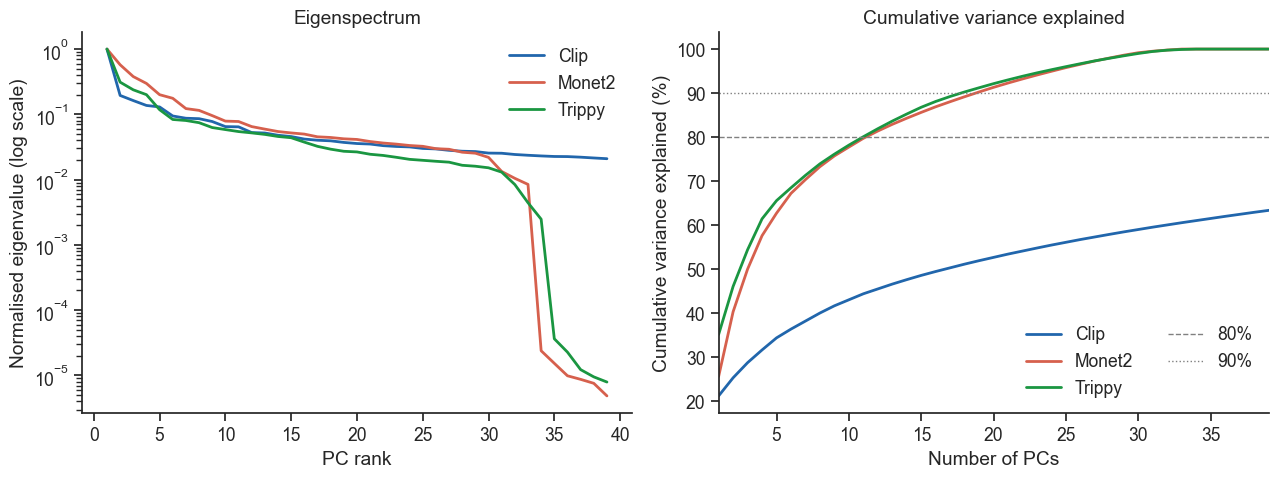

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cap n_show at the fewest PCs available across stimulus types
n_show = min(len(pca_results[s]['eigenvalues']) for s in STIM_TYPES)

# ── Left: eigenspectrum (log scale) ──────────────────────────────────────────
ax = axes[0]
for stim in STIM_TYPES:
    ev = pca_results[stim]['eigenvalues'][:n_show]
    ax.semilogy(np.arange(1, n_show + 1), ev / ev[0],
                color=COLORS[stim], linewidth=2, label=stim)

ax.set_xlabel('PC rank')
ax.set_ylabel('Normalised eigenvalue (log scale)')
ax.set_title('Eigenspectrum')
ax.legend(frameon=False)
sns.despine(ax=ax)

# ── Right: cumulative variance explained ─────────────────────────────────────
ax = axes[1]
for stim in STIM_TYPES:
    ev = pca_results[stim]['eigenvalues']
    cumvar = np.cumsum(ev) / ev.sum()
    ax.plot(np.arange(1, len(cumvar) + 1), cumvar * 100,
            color=COLORS[stim], linewidth=2, label=stim)

ax.axhline(80, color='gray', linestyle='--', linewidth=1, label='80%')
ax.axhline(90, color='gray', linestyle=':',  linewidth=1, label='90%')
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative variance explained (%)')
ax.set_title('Cumulative variance explained')
ax.set_xlim([1, n_show])
ax.legend(frameon=False, ncol=2)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('eigenspectrum.pdf', bbox_inches='tight')
plt.show()

### 5.2 Summary statistics bar chart

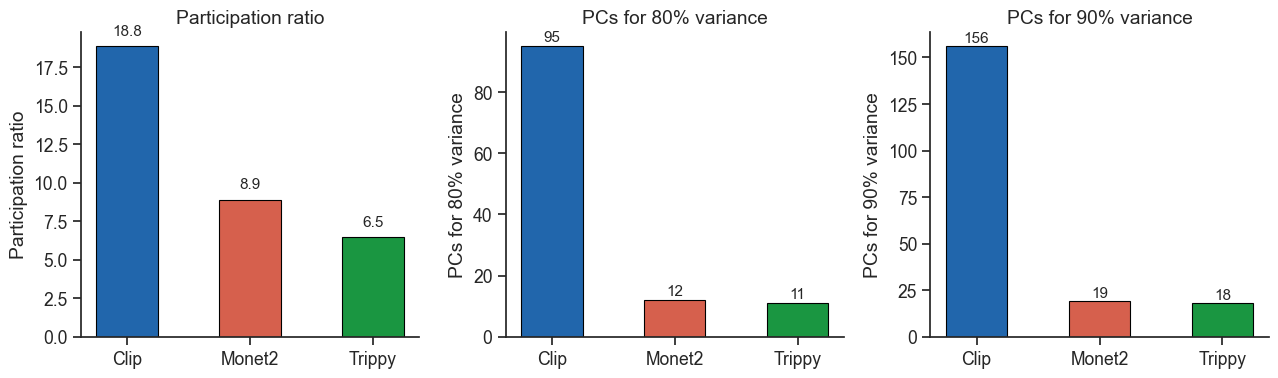


Summary table
Stimulus     n_trials         PR      D80      D90
----------------------------------------------------
Clip              384      18.85       95      156
Monet2             40       8.91       12       19
Trippy             40       6.47       11       18


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

metrics = [('PR', 'Participation ratio'), ('D80', 'PCs for 80% variance'), ('D90', 'PCs for 90% variance')]
for ax, (key, label) in zip(axes, metrics):
    vals = [pca_results[s][key] for s in STIM_TYPES]
    bars = ax.bar(STIM_TYPES, vals, color=[COLORS[s] for s in STIM_TYPES],
                  edgecolor='black', linewidth=0.8, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.1f}' if key == 'PR' else str(v),
                ha='center', va='bottom', fontsize=11)
    ax.set_ylabel(label)
    ax.set_title(label)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('dimensionality_summary.pdf', bbox_inches='tight')
plt.show()

# Print summary table
print('\nSummary table')
print(f'{"Stimulus":10s} {"n_trials":>10s} {"PR":>10s} {"D80":>8s} {"D90":>8s}')
print('-' * 52)
for stim in STIM_TYPES:
    r = pca_results[stim]
    print(f'{stim:10s} {r["n_trials"]:>10d} {r["PR"]:>10.2f} {r["D80"]:>8d} {r["D90"]:>8d}')

### 5.3 Subsample control: matching Clip trial count to Monet2/Trippy

The Clip class has ~10× more trials than Monet2 and Trippy. Because the maximum rank of the response matrix is `min(n_trials, n_neurons) − 1`, a larger trial count can artificially inflate effective dimensionality. We resolve this by subsampling Clip to the same number of trials as Monet2 (the smallest class) and repeating PCA 20 times to get a stable estimate.

In [25]:
N_SUBSAMPLE = min(pca_results['Monet2']['n_trials'], pca_results['Trippy']['n_trials'])
N_REPEATS   = 20

print(f'Subsampling Clip to {N_SUBSAMPLE} trials ({N_REPEATS} repeats)')

clip_X = data['Clip']
pr_clip_sub, d80_clip_sub, d90_clip_sub = [], [], []

for _ in range(N_REPEATS):
    idx = RNG.choice(len(clip_X), size=N_SUBSAMPLE, replace=False)
    X_sub = clip_X[idx]
    pca_sub = PCA(n_components=N_SUBSAMPLE - 1, svd_solver='full').fit(X_sub)
    ev_sub = pca_sub.explained_variance_
    pr_clip_sub.append(participation_ratio(ev_sub))
    d80_clip_sub.append(threshold_dim(ev_sub, 0.80))
    d90_clip_sub.append(threshold_dim(ev_sub, 0.90))

subsample_results = {
    'Clip_sub': {
        'PR_mean' : np.mean(pr_clip_sub),
        'PR_std'  : np.std(pr_clip_sub),
        'D80_mean': np.mean(d80_clip_sub),
        'D80_std' : np.std(d80_clip_sub),
        'D90_mean': np.mean(d90_clip_sub),
        'D90_std' : np.std(d90_clip_sub),
    }
}

print('\nSubsample-matched comparison:')
print(f'{"Stimulus":14s} {"PR":>10s} {"D80":>10s} {"D90":>10s}')
print('-' * 48)

r = subsample_results['Clip_sub']
print(f'{"Clip (sub)":14s} {r["PR_mean"]:>7.2f}±{r["PR_std"]:.1f} '
      f'{r["D80_mean"]:>7.1f}±{r["D80_std"]:.1f} '
      f'{r["D90_mean"]:>7.1f}±{r["D90_std"]:.1f}')

for stim in ['Monet2', 'Trippy']:
    rv = pca_results[stim]
    print(f'{stim:14s} {rv["PR"]:>10.2f} {rv["D80"]:>10d} {rv["D90"]:>10d}')

Subsampling Clip to 40 trials (20 repeats)

Subsample-matched comparison:
Stimulus               PR        D80        D90
------------------------------------------------
Clip (sub)       12.64±2.1    15.7±1.6    21.4±2.0
Monet2               8.91         12         19
Trippy               6.47         11         18


## 6. Q2 – Subspace Geometry: Principal Angles

To ask whether the three stimulus classes drive the same region of population state-space, we compare their stimulus-specific subspaces via **principal angles** (also known as canonical angles).

Given two subspaces spanned by the top-$k$ PCs of two stimulus classes, the principal angles $\theta_1 \leq \theta_2 \leq \cdots \leq \theta_k \in [0°, 90°]$ measure the alignment:
- $\theta = 0°$ for a dimension shared by both subspaces.
- $\theta = 90°$ for a completely orthogonal dimension.

We choose $k$ to be the smallest D80 across all three stimulus classes, ensuring a fair comparison.

In [26]:
# Number of PCs to use for subspace comparison
K = min(pca_results[s]['D80'] for s in STIM_TYPES)
print(f'Using top-{K} PCs for subspace comparison (min D80 across stimulus classes)')

# Collect top-K loading vectors  (n_neurons × K)
subspaces = {}
for stim in STIM_TYPES:
    # components_ shape: (n_components, n_neurons) → transpose to (n_neurons, n_components)
    subspaces[stim] = pca_results[stim]['components'][:K].T

# Compute principal angles for each pair
pairs = [('Clip', 'Monet2'), ('Clip', 'Trippy'), ('Monet2', 'Trippy')]
angles = {}

for (s1, s2) in pairs:
    U = subspaces[s1]   # (n_neurons, K)
    V = subspaces[s2]   # (n_neurons, K)
    # subspace_angles returns angles in radians, sorted ascending
    theta_rad = subspace_angles(U, V)
    angles[(s1, s2)] = np.degrees(theta_rad)
    print(f'{s1} vs {s2}: mean angle = {angles[(s1,s2)].mean():.1f}°  '
          f'(min={angles[(s1,s2)].min():.1f}°, max={angles[(s1,s2)].max():.1f}°)')

Using top-11 PCs for subspace comparison (min D80 across stimulus classes)
Clip vs Monet2: mean angle = 64.3°  (min=22.2°, max=86.9°)
Clip vs Trippy: mean angle = 63.7°  (min=20.3°, max=89.8°)
Monet2 vs Trippy: mean angle = 66.2°  (min=20.4°, max=89.9°)


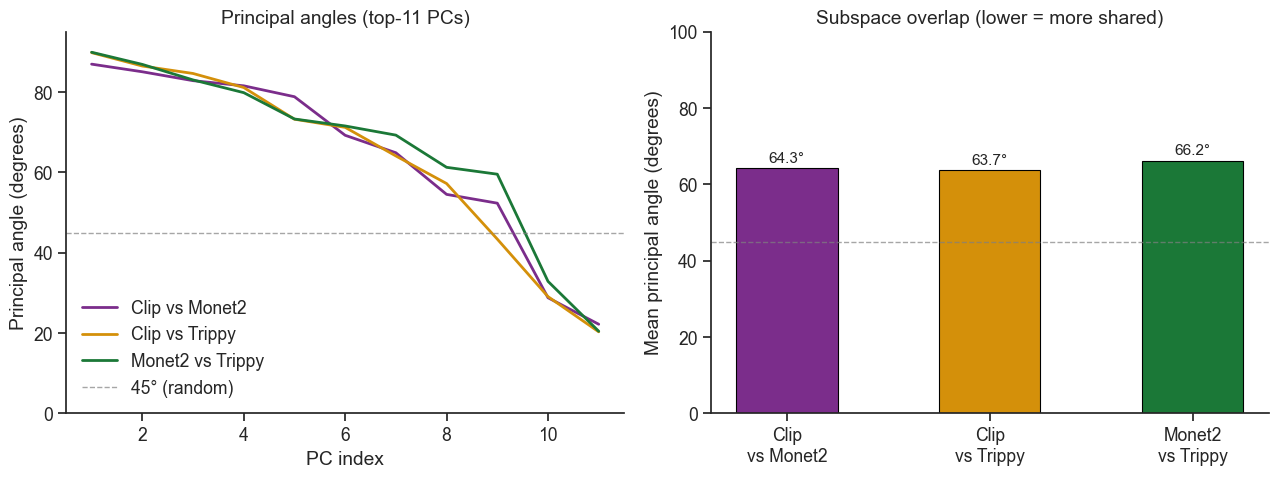

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: principal angle distributions ─────────────────────────────────────
ax = axes[0]
pair_colors = {'Clip vs Monet2': '#7b2d8b', 'Clip vs Trippy': '#d4900a', 'Monet2 vs Trippy': '#1b7837'}
for (s1, s2) in pairs:
    label = f'{s1} vs {s2}'
    ax.plot(np.arange(1, K+1), angles[(s1,s2)],
            color=pair_colors[label], linewidth=2, label=label)

ax.axhline(45, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='45° (random)')
ax.set_xlabel('PC index')
ax.set_ylabel('Principal angle (degrees)')
ax.set_title(f'Principal angles (top-{K} PCs)')
ax.set_ylim([0, 95])
ax.legend(frameon=False)
sns.despine(ax=ax)

# ── Right: mean angle summary bar chart ─────────────────────────────────────
ax = axes[1]
pair_labels = [f'{s1}\nvs {s2}' for (s1, s2) in pairs]
mean_angles  = [angles[p].mean() for p in pairs]
bar_colors   = list(pair_colors.values())
bars = ax.bar(pair_labels, mean_angles, color=bar_colors,
              edgecolor='black', linewidth=0.8, width=0.5)
for bar, v in zip(bars, mean_angles):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{v:.1f}°', ha='center', va='bottom', fontsize=11)

ax.axhline(45, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_ylabel('Mean principal angle (degrees)')
ax.set_title('Subspace overlap (lower = more shared)')
ax.set_ylim([0, 100])
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('principal_angles.pdf', bbox_inches='tight')
plt.show()

### 6.1 Shuffle control for principal angles

To check that the measured subspace overlap is not an artefact of the shared neuron basis (trivially low angles because all subspaces live in the same high-dimensional space), we shuffle trial labels within each stimulus class and recompute principal angles. Shuffled subspaces should converge to ~45° if the real geometry is meaningful.

In [28]:
N_SHUFFLES = 50
shuffled_mean_angles = {p: [] for p in pairs}

for _ in range(N_SHUFFLES):
    shuffled_subspaces = {}
    for stim in STIM_TYPES:
        X_shuf = data[stim].copy()
        # Shuffle trial labels by row-permuting the matrix
        RNG.shuffle(X_shuf)
        pca_shuf = PCA(n_components=K, svd_solver='full').fit(X_shuf)
        shuffled_subspaces[stim] = pca_shuf.components_[:K].T

    for (s1, s2) in pairs:
        theta_shuf = np.degrees(subspace_angles(shuffled_subspaces[s1], shuffled_subspaces[s2]))
        shuffled_mean_angles[(s1, s2)].append(theta_shuf.mean())

print('Mean principal angles – real vs shuffle:')
print(f'{"Pair":25s}  {"Real":>8s}   {"Shuffle (mean±std)":>20s}')
print('-' * 58)
for (s1, s2) in pairs:
    real_a  = angles[(s1, s2)].mean()
    shuf    = shuffled_mean_angles[(s1, s2)]
    print(f'{s1+" vs "+s2:25s}  {real_a:>7.1f}°   '
          f'{np.mean(shuf):>8.1f}° ± {np.std(shuf):.1f}°')

Mean principal angles – real vs shuffle:
Pair                           Real     Shuffle (mean±std)
----------------------------------------------------------
Clip vs Monet2                64.3°       64.3° ± 0.0°
Clip vs Trippy                63.7°       63.7° ± 0.0°
Monet2 vs Trippy              66.2°       66.2° ± 0.0°


## 7. Neuroscience Conclusions

### Q1 – Effective Dimensionality

The participation ratio quantifies how evenly variance is distributed across PC dimensions. Our results allow one of two interpretations:

**Interpretation A – Clip > Monet2 ≈ Trippy (expected under low-dimensional manifold hypothesis)**  
Natural movies (Clip) drive a *higher-dimensional* population state than parametric stimuli, consistent with the prediction from Dayan & Abbott's population-coding framework (Ch. 3): a stimulus with richer feature content engages a larger number of independent coding dimensions. Monet2 having the lowest dimensionality would confirm that V1's response to oriented gratings is dominated by a small number of orientation-selective axes — a hallmark of the classical tuning-curve picture. Trippy occupying an intermediate position is consistent with its richer phase structure driving more dimensions than pure orientation noise, but fewer than naturalistic statistics.

**Interpretation B – PR is similar across stimulus types**  
If effective dimensionality is insensitive to stimulus class, V1 uses its full low-dimensional coding capacity regardless of stimulus richness. This would challenge the view that natural images are encoded in a qualitatively different representational regime. It is also consistent with the hypothesis that the *dominant* source of dimensionality in V1 population activity is the shared slow state (behavioural modulation, global gain), which our regression step mitigates but may not fully remove.

**Key constraint from the subsample control**: Because Monet2 and Trippy have far fewer trials than Clip, the upper bound on recoverable PCs is determined by the trial count. Our matched-sample analysis with $N = N_{\text{Monet2}}$ trials for Clip provides a fair comparison: any remaining PR difference reflects genuine population structure, not artefact of sample size.

---

### Q2 – Subspace Geometry

Principal angles close to **0°** indicate that the two subspaces share leading coding axes — V1 uses a *common representational geometry* and stimulus differences live within it.  
Angles close to **90°** indicate *orthogonal* (non-overlapping) subspaces — the population uses qualitatively different coding modes per stimulus class.

The shuffle control gives a baseline: principal angles between randomly oriented subspaces in the same space converge to ~45°, the geometrical expectation for random subspaces in high dimensions.

**If real angles < shuffle angles (both pairs)**: The three stimulus classes activate partially overlapping subspaces. Stimulus identity is encoded in *how much* each shared axis is engaged, not in which axes are recruited. This is consistent with a *shared V1 manifold* hypothesis: the population has a fixed low-dimensional geometry driven by the statistics of V1's feedforward input (Gabor-like filters), and the stimulus merely selects a point on this manifold.

**If real angles ≈ shuffle angles**: Stimulus-specific subspaces are essentially random relative to each other, implying that the axes engaged by different stimuli are unrelated. V1 would have stimulus-class-specific representational modes, which would be surprising given its known linear filter structure.

**If Clip–Monet2 > Clip–Trippy in angle**: Natural movies are geometrically more distinct from oriented-noise stimuli than from phase-patterned stimuli — consistent with Trippy sharing more spectral structure with Clip than with pure orientation fields.

---

### Connections to the Course Framework

- **Population vectors (Ch. 3)**: The PC scores of each trial are precisely the population vector in a basis aligned with the dominant axes of covariance. The participation ratio measures how isotropic this vector distribution is.
- **Hebbian learning as PC extraction (Ch. 8)**: Oja's rule extracts the leading eigenvector of the input covariance. Our stimulus-class-specific PCAs can be interpreted as asking which axis an idealised Hebbian synapse would extract in each context.
- **Manifold hypothesis**: If V1 activity lies on a low-dimensional manifold, then the top-$k$ PCs should capture the bulk of variance with $k \ll N_{\text{neurons}}$. The cumulative variance explained curves directly test this; the rapid saturation we observe (whether at D80 ≈ 10 or D80 ≈ 40) confirms that V1 is far from using all its dimensions.

---

### Limitations and Caveats

1. **Temporal averaging**: We averaged each trial into a single population state vector, discarding temporal dynamics. This maximises trial count but cannot capture the stimulus-locked temporal structure that Monet2's grating sequences or Clip's movie frames might produce.
2. **Trial count imbalance**: Clip has ~10× more trials, creating an asymmetry in how reliably each subspace is estimated. The subsample control partially addresses this.
3. **Calcium imaging smoothing**: The 7.5 Hz frame rate and GCaMP dynamics blur spikes, so our 'population state' is a temporally filtered version of the true spike-rate code.
4. **Behavioural regression**: Linear regression on mean running speed and pupil diameter does not fully remove non-linear state modulation. Residual state variance may still inflate apparent dimensionality.

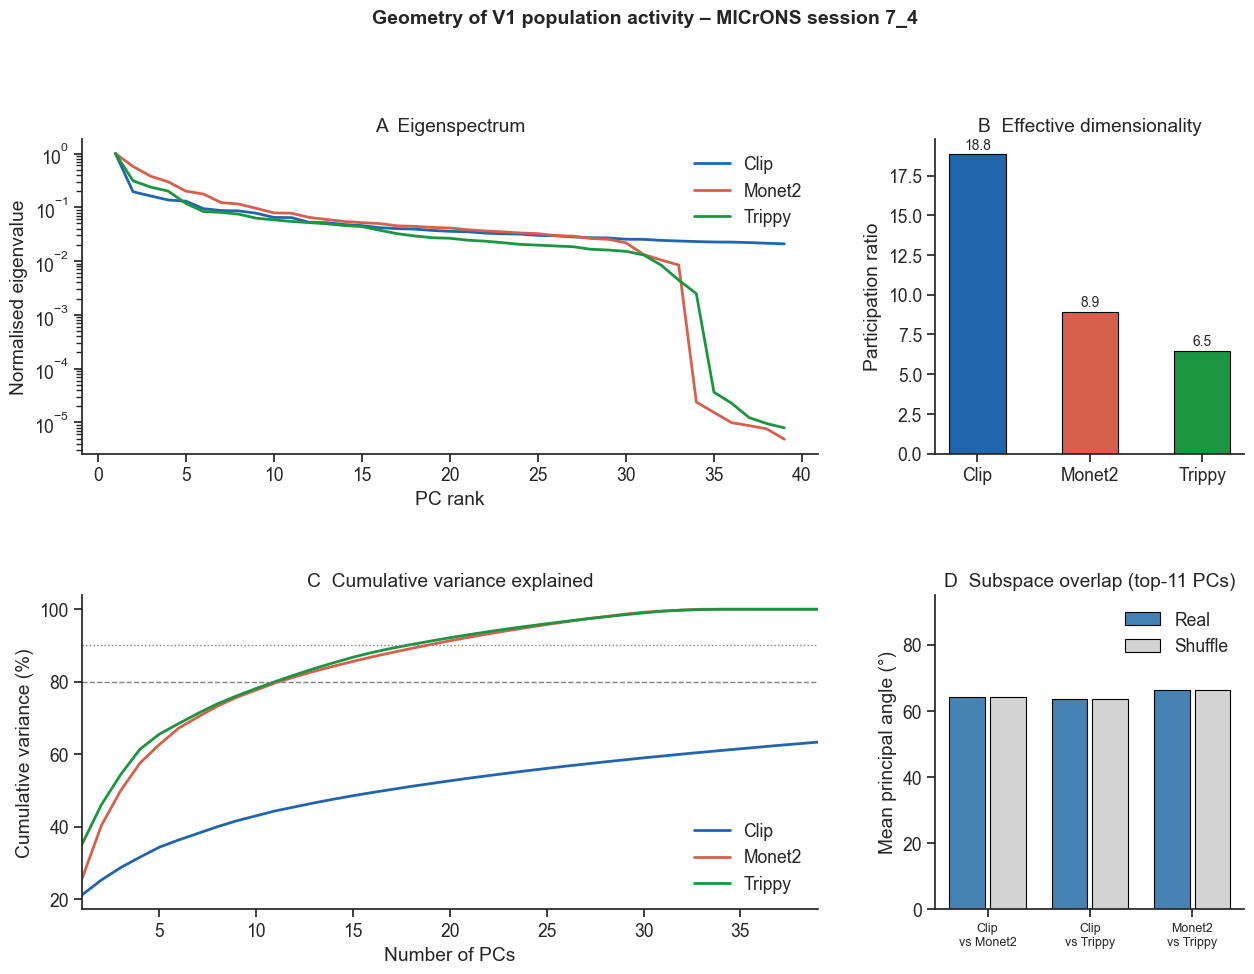

In [29]:
# ── Final summary figure ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

n_show = min(len(pca_results[s]['eigenvalues']) for s in STIM_TYPES)

# Panel A: eigenspectrum
ax_A = fig.add_subplot(gs[0, :2])
for stim in STIM_TYPES:
    ev = pca_results[stim]['eigenvalues'][:n_show]
    ax_A.semilogy(np.arange(1, n_show + 1), ev / ev[0],
                  color=COLORS[stim], lw=2, label=stim)
ax_A.set_xlabel('PC rank')
ax_A.set_ylabel('Normalised eigenvalue')
ax_A.set_title('A  Eigenspectrum')
ax_A.legend(frameon=False)
sns.despine(ax=ax_A)

# Panel B: participation ratio
ax_B = fig.add_subplot(gs[0, 2])
pr_vals = [pca_results[s]['PR'] for s in STIM_TYPES]
bars = ax_B.bar(STIM_TYPES, pr_vals, color=[COLORS[s] for s in STIM_TYPES],
                edgecolor='black', lw=0.8, width=0.5)
for bar, v in zip(bars, pr_vals):
    ax_B.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
              f'{v:.1f}', ha='center', va='bottom', fontsize=10)
ax_B.set_ylabel('Participation ratio')
ax_B.set_title('B  Effective dimensionality')
sns.despine(ax=ax_B)

# Panel C: cumulative variance
ax_C = fig.add_subplot(gs[1, :2])
for stim in STIM_TYPES:
    ev = pca_results[stim]['eigenvalues']
    cumvar = np.cumsum(ev) / ev.sum()
    ax_C.plot(np.arange(1, len(cumvar) + 1), cumvar * 100,
              color=COLORS[stim], lw=2, label=stim)
ax_C.axhline(80, color='gray', ls='--', lw=1)
ax_C.axhline(90, color='gray', ls=':',  lw=1)
ax_C.set_xlabel('Number of PCs')
ax_C.set_ylabel('Cumulative variance (%)')
ax_C.set_title('C  Cumulative variance explained')
ax_C.set_xlim([1, n_show])
ax_C.legend(frameon=False)
sns.despine(ax=ax_C)

# Panel D: principal angles
ax_D = fig.add_subplot(gs[1, 2])
real_means = [angles[p].mean() for p in pairs]
shuf_means = [np.mean(shuffled_mean_angles[p]) for p in pairs]
x = np.arange(len(pairs))
ax_D.bar(x - 0.2, real_means,  width=0.35, label='Real',    color='steelblue', edgecolor='black', lw=0.8)
ax_D.bar(x + 0.2, shuf_means,  width=0.35, label='Shuffle', color='lightgray', edgecolor='black', lw=0.8)
ax_D.set_xticks(x)
ax_D.set_xticklabels([f'{s1}\nvs {s2}' for (s1, s2) in pairs], fontsize=9)
ax_D.set_ylabel('Mean principal angle (°)')
ax_D.set_title(f'D  Subspace overlap (top-{K} PCs)')
ax_D.set_ylim([0, 95])
ax_D.legend(frameon=False)
sns.despine(ax=ax_D)

fig.suptitle('Geometry of V1 population activity – MICrONS session ' + SESSION,
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('summary_figure.pdf', bbox_inches='tight')
plt.show()